# M4a: Real CNN on MNIST with the TorchAdapter

**Phase 3, first TorchAdapter example.** We leave the toy datasets behind and train
a real convolutional neural network on MNIST (28×28 handwritten digits) using the
*exact same* six-stage pipeline as M1 (sklearn) and M2–M3 (numpy).

The only difference is the **adapters**: instead of `SklearnModel` / `NumpyModel`,
we use `TorchModel`, `TorchLoss`, and `TorchOptimizer` to wrap PyTorch. PyTorch's
autograd handles the gradients — just like backpropagation did by hand in M3, but
now it scales to a CNN.

**Full data path demonstrated:**
`ImageFolderDataSource → TransformedDataStream → TorchModel → TorchLoss → TorchOptimizer → BasePipeline.run("train")`

**Target:** > 95% test accuracy in about two minutes.

In [ ]:
# Notebooks are examples, not core: imports live at top level here.
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms as T

# The pipeline operates on protocols; the torch adapters satisfy them.
from pipeline.config import Config
from pipeline.data.image_folder import ImageFolderDataSource
from pipeline.data.transforms import TransformedDataStream
from pipeline.evaluation.metrics import Metrics, accuracy
from pipeline.pipeline import BasePipeline, PipelineState
from pipeline.adapters.torch_adapter import TorchLoss, TorchModel, TorchOptimizer
from pipeline.protocols import Batch
from pipeline.utils.seed import set_seed

# Use a GPU when one is available, else CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print("Pipeline components: TorchModel, TorchLoss, TorchOptimizer")

In [2]:
# Download MNIST and write PNGs on disk into an ImageFolder structure:
# train/0/, train/1/, ... and val/0/, val/1/, ...
#
# ImageFolderDataSource reads one subfolder per class and assigns integer labels
# in alphabetical order, so the folder names are zero-padded ("07", not "7") so
# the class order matches digit order.

# Raw MNIST is cached under ~/.cache (torchvision's default search path), so it is
# downloaded only once and reused on every re-run of this notebook.
MNIST_CACHE = Path("~/.cache/torchvision").expanduser()

# The written ImageFolder structure goes in a scratch dir (per-execution).
DATA_DIR = Path(tempfile.mkdtemp(prefix="mnist_pipeline_"))
TRAIN_ROOT = DATA_DIR / "train"    # ImageFolder train root
VAL_ROOT = DATA_DIR / "val"        # ImageFolder validation root


def write_mnist_to_folders(split: str, dest: Path) -> None:
    """Download one MNIST split and write it as class subfolders of PNGs."""
    ds = torchvision.datasets.MNIST(
        root=str(MNIST_CACHE), train=(split == "train"), download=True
    )
    # Per-class file counter (avoids re-listing the folder for every image).
    counts: dict[int, int] = {}
    for img, label in ds:
        folder = dest / f"{label:02d}"
        folder.mkdir(parents=True, exist_ok=True)
        i = counts.get(label, 0)
        img.save(folder / f"{i:05d}.png")
        counts[label] = i + 1


print("Writing train images...")
write_mnist_to_folders("train", TRAIN_ROOT)
print("Writing validation images...")
write_mnist_to_folders("test", VAL_ROOT)

train_n = sum(len(list(p.glob("*.png"))) for p in TRAIN_ROOT.iterdir())
val_n = sum(len(list(p.glob("*.png"))) for p in VAL_ROOT.iterdir())
print(f"Train images: {train_n}   Val images: {val_n}")
print(f"Class folders: {sorted(p.name for p in TRAIN_ROOT.iterdir())}")

Writing train images...


Writing validation images...


Train images: 60000   Val images: 10000
Class folders: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [ ]:
# A small but real CNN. MNIST is 28x28 grayscale (single channel).
#
# Spatial dimension math for a 28x28 input (kernel 3, no padding, stride 1;
# MaxPool2d(2) halves the side):
#   28 -> conv -> 26 -> pool -> 13 -> conv -> 11 -> pool -> 5
# so the flattened feature vector is 5 * 5 * 64 = 1600 long.
n_features = 5 * 5 * 64


class MNISTCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),   # 28 -> 26
            nn.ReLU(),
            nn.MaxPool2d(2),                    # 26 -> 13
            nn.Conv2d(32, 64, kernel_size=3),  # 13 -> 11
            nn.ReLU(),
            nn.MaxPool2d(2),                    # 11 -> 5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),                 # 10 digit classes
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

In [ ]:
# The pipeline stage implementations. This is the same Template Method as M1/M3;
# only the adapters differ.
class MNISTPipeline(BasePipeline):
    def __init__(self, config: Config) -> None:
        super().__init__(config)
        # torchvision transform: PIL image -> (1, 28, 28) float tensor, then
        # normalize pixel values from [0, 1] to ~[-1, 1].
        self.to_tensor = T.Compose(
            [T.ToTensor(), T.Normalize(mean=(0.1307,), std=(0.3081,))]
        )

    def _foldered_stream(self, root: Path) -> TransformedDataStream:
        """ImageFolderDataSource -> TransformedDataStream (PIL list -> tensor)."""
        source = ImageFolderDataSource(
            root, batch_size=self.config.batch_size, shuffle=True, seed=self.config.seed
        )

        def to_tensor_batch(batch: Batch) -> Batch:
            # Stack a batch of PIL Images into one (batch, 1, 28, 28) tensor.
            x = torch.stack([self.to_tensor(img) for img in batch.inputs])
            return Batch(
                inputs=x.to(DEVICE),
                targets=torch.as_tensor(batch.targets).to(DEVICE),
            )

        return TransformedDataStream(source, to_tensor_batch)

    def load_data(self, state: PipelineState) -> None:
        state.data_stream = self._foldered_stream(TRAIN_ROOT)
        state.val_data_stream = self._foldered_stream(VAL_ROOT)

    def build_model(self, state: PipelineState) -> None:
        # Seed BEFORE constructing the module so weight initialization is
        # reproducible across runs. Building the model HERE -- inside the stage,
        # not as a module-level global -- keeps each run self-contained and routes
        # the model through the state bus.
        set_seed(self.config.seed, deterministic=True)
        state.model = TorchModel(MNISTCNN().to(DEVICE))
        print(f"CNN parameters: {sum(p.numel() for p in state.model._module.parameters()):,}")
        # Tensor inputs keep the autograd graph intact, so TorchLoss does NOT need
        # a model= for rebinding (that is only needed for detached numpy input).
        state.loss_fn = TorchLoss("CrossEntropyLoss")
        state.optimizer = TorchOptimizer(
            state.model.parameters(), "Adam", lr=self.config.learning_rate
        )
        state.metrics = Metrics(accuracy=accuracy)

    def evaluate(self, state: PipelineState) -> None:
        state.model.eval_mode()
        preds, trues = [], []
        with torch.no_grad():
            for batch in state.val_data_stream:
                logits = state.model.forward(batch.inputs)
                preds.extend(torch.argmax(logits, dim=1).tolist())
                trues.extend(batch.targets.tolist())
        state.metrics.compute(np.array(trues), np.array(preds))

    def export(self, state: PipelineState) -> None:
        # In a real system we would write checkpoints + predictions to disk. For
        # this teaching notebook, just mark the state bus so the stage runs.
        state.predictions = np.array([0])

In [5]:
# Same Config as every other example; nothing torch-specific here.
config = Config(
    batch_size=128,
    num_epochs=5,
    learning_rate=0.001,
    seed=42,
    task_name="m4a-mnist-cnn",
    output_dir=str(DATA_DIR / "output"),
)

pipeline = MNISTPipeline(config)
print(
    "Config batch_size:",
    config.batch_size,
    "| epochs:",
    config.num_epochs,
    "| lr:",
    config.learning_rate,
)

Config batch_size: 128 | epochs: 5 | lr: 0.001


In [6]:
# Run the full six-stage pipeline. run("train") does:
#   load_data -> extract_features (no-op) -> build_model -> train -> evaluate -> export
import time

from pipeline.hooks.progress import ProgressHook

pipeline.add_hook(ProgressHook())

start = time.time()
state = pipeline.run("train")
elapsed = time.time() - start

acc = state.metrics["accuracy"]

print(f"\nTraining time:        {elapsed:.1f}s")
print(f"Validation accuracy:  {acc:.4f}  ({acc * 100:.1f}%)")
print(f"Final training loss:  {state.history['loss'][-1]:.4f}")

Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1:   0%|          | 1/469 [00:02<21:59,  2.82s/it]

Epoch 1:   0%|          | 1/469 [00:02<21:59,  2.82s/it, loss=2.2960]

Epoch 1:   0%|          | 2/469 [00:02<21:56,  2.82s/it, loss=2.2813]

Epoch 1:   1%|          | 3/469 [00:02<21:53,  2.82s/it, loss=2.1847]

...

Epoch 5: 100%|█████████▉| 468/469 [00:06<00:00, 73.02it/s, loss=0.0899]

Epoch 5: 100%|██████████| 469/469 [00:06<00:00, 74.33it/s, loss=0.0899]

Epoch 5: 100%|██████████| 469/469 [00:06<00:00, 74.33it/s, loss=0.0943]

Epoch 5: 100%|██████████| 469/469 [00:06<00:00, 70.41it/s, loss=0.0943]


Training time:        39.1s
Validation accuracy:  0.9914  (99.1%)
Final training loss:  0.0943


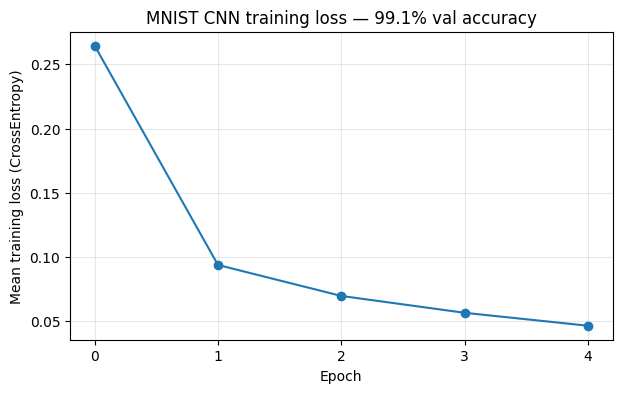

In [7]:
# The training history holds one loss value per batch. Smooth it per-epoch and plot.
losses = state.history["loss"]
num_epochs = config.num_epochs
batches_per_epoch = len(losses) // num_epochs
epoch_losses = [
    np.mean(losses[e * batches_per_epoch : (e + 1) * batches_per_epoch])
    for e in range(num_epochs)
]

plt.figure(figsize=(7, 4))
plt.plot(epoch_losses, marker="o")
plt.xticks(range(num_epochs))
plt.xlabel("Epoch")
plt.ylabel("Mean training loss (CrossEntropy)")
plt.title(f"MNIST CNN training loss \u2014 {acc * 100:.1f}% val accuracy")
plt.grid(True, alpha=0.3)
plt.show()

## Wrap-up

That is the same pipeline from M1/M3 operating on real images. Nothing in
`BasePipeline` knew about CNNs, convolutions, or PyTorch — the **protocols and
adapters** carried all of it:

| Component | This example | Why it works |
|---|---|---|
| `ImageFolderDataSource` | reads `train/0/\u2026` folders | DataStream: yields PIL `Batch` |
| `TransformedDataStream` | `ToTensor + Normalize` per batch | decorator maps Batch → Batch |
| `TorchModel` | wraps `MNISTCNN` | `forward / parameters / train_mode / eval_mode` |
| `TorchLoss` | `CrossEntropyLoss` | wraps `Loss` with a `backward()` |
| `TorchOptimizer` | `Adam` | drives gradient updates in-place |
| `BasePipeline` | `run("train")` | six-stage Template Method |

**Key autograd note:** because `ImageFolderDataSource` uses torch *tensor* input,
the forward pass keeps the autograd graph alive, so `TorchLoss` needs **no**
`model=` rebinding. That parameter is only required on the CSV/numpy path where
`TorchModel.forward` returns a detached numpy array and the graph would otherwise
be severed.
To go further: add data augmentation (`RandomCrop`, `Rotation`) in
`to_tensor_batch`, raise `num_epochs`, or swap the optimizer to `SGD` with momentum.